# Workbook local — MobileNet Thrips

## Résultats générés (dans OUTPUT_DIR)
- `mobilenet_thrips_autres.keras` : modèle complet
- `best_loss.weights.h5` : meilleurs poids (validation)
- `final.weights.h5` : poids finaux
- `history.csv` : courbes d'entraînement
- `confusion_matrix.png` : matrice de confusion


In [1]:
# Imports

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import backend
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from tensorflow.keras.optimizers import SGD

from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt

print('TensorFlow:', tf.__version__)


TensorFlow: 2.10.1


In [2]:
# Paramétrage


# Dataset
DATASET_ROOT = Path("./AI4I_2026_JDD_V0")
CLASSES = ["0_thrips", "AUTRES"]
N_CLASSES = len(CLASSES)

# Sorties
OUTPUT_DIR = Path("./Travail_IA") / "thrips_vs_autres"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Entraînement
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 15
SEED = 42

# Split dataset
TEST_SIZE = 0.10         # 10% test
VAL_SIZE = 0.20          # 20% validation (sur le restant train)

print('DATASET_ROOT =', DATASET_ROOT.resolve())
print('OUTPUT_DIR   =', OUTPUT_DIR.resolve())
print('CLASSES      =', CLASSES)

DATASET_ROOT = D:\Cours_master\AI4I\AI4I_2026_JDD_V0
OUTPUT_DIR   = D:\Cours_master\AI4I\Travail_IA\thrips_vs_autres
CLASSES      = ['0_thrips', 'AUTRES']


In [3]:
# Scan du dataset

IMG_EXT = (".png")

paths = []
labels = []

for idx, cls in enumerate(CLASSES):
    cls_dir = DATASET_ROOT / cls
    if not cls_dir.exists():
        raise FileNotFoundError(f"Dossier manquant: {cls_dir}")

    cls_files = [p for p in cls_dir.rglob('*') if p.is_file() and p.suffix.lower() in IMG_EXT]
    print(f"{cls:10s} -> {len(cls_files)} images")

    paths.extend([str(p) for p in cls_files])
    labels.extend([idx] * len(cls_files))

paths = np.array(paths)
labels = np.array(labels)

if len(paths) == 0:
    raise RuntimeError("Aucune image détectée. Vérifie DATASET_ROOT et extensions.")

print('Total images:', len(paths))


0_thrips   -> 780 images
AUTRES     -> 3500 images
Total images: 4280


In [4]:
# Split train / val / test

# 1) Train+Val / Test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    paths,
    labels,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=labels
)

# 2) Train / Val (sur le restant)
val_ratio = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_ratio,
    random_state=SEED,
    stratify=y_trainval
)

print('Train:', len(X_train))
print('Val  :', len(X_val))
print('Test :', len(X_test))


Train: 2995
Val  : 857
Test : 428


In [5]:
tf.data

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label, training=False):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)

    img = preprocess_input(img)

    return img, tf.one_hot(label, depth=N_CLASSES)


def build_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l, training=training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(X_train, y_train, training=True)
val_ds   = build_dataset(X_val, y_val, training=False)
test_ds  = build_dataset(X_test, y_test, training=False)

print('Datasets prêts.')

Datasets prêts.


In [6]:
# Modèle MobileNet (classification binaire)

tf.keras.utils.set_random_seed(SEED)

base = MobileNet(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(1024, activation='relu')(x)
out = Dense(N_CLASSES, activation='softmax')(x)

model = Model(inputs=base.input, outputs=out)

model.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=1e-4, momentum=0.9),
    metrics=['accuracy']
)

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 64, 64, 32)        864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 64, 64, 32)       128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 64, 64, 32)        0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 64, 64, 32)       288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 64, 64, 32)       128       
 ation)                                                      

In [7]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

tf.debugging.set_log_device_placement(True)


TF version: 2.10.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
# Entraînement

best_weights_path = OUTPUT_DIR / 'best_loss.weights.h5'
final_weights_path = OUTPUT_DIR / 'final.weights.h5'
model_path = OUTPUT_DIR / 'mobilenet_thrips_autres.keras'
history_path = OUTPUT_DIR / 'history.csv'

callbacks = [
    ModelCheckpoint(
        filepath=str(best_weights_path),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    CSVLogger(str(history_path))
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

# Sauvegardes
model.save(str(model_path))
model.save_weights(str(final_weights_path))

print('Modèle sauvegardé :', model_path)
print('Poids best loss :', best_weights_path)
print('Poids finaux :', final_weights_path)
print('Historique :', history_path)


Epoch 1/15

Epoch 1: val_loss improved from inf to 0.39504, saving model to Travail_IA\thrips_vs_autres\best_loss.weights.h5
94/94 - 10s - loss: 0.4877 - accuracy: 0.7843 - val_loss: 0.3950 - val_accuracy: 0.8191 - 10s/epoch - 104ms/step
Epoch 2/15

Epoch 2: val_loss improved from 0.39504 to 0.33384, saving model to Travail_IA\thrips_vs_autres\best_loss.weights.h5
94/94 - 2s - loss: 0.3740 - accuracy: 0.8274 - val_loss: 0.3338 - val_accuracy: 0.8390 - 2s/epoch - 19ms/step
Epoch 3/15

Epoch 3: val_loss improved from 0.33384 to 0.29876, saving model to Travail_IA\thrips_vs_autres\best_loss.weights.h5
94/94 - 2s - loss: 0.3274 - accuracy: 0.8528 - val_loss: 0.2988 - val_accuracy: 0.8611 - 2s/epoch - 18ms/step
Epoch 4/15

Epoch 4: val_loss improved from 0.29876 to 0.27789, saving model to Travail_IA\thrips_vs_autres\best_loss.weights.h5
94/94 - 2s - loss: 0.3016 - accuracy: 0.8608 - val_loss: 0.2779 - val_accuracy: 0.8961 - 2s/epoch - 19ms/step
Epoch 5/15

Epoch 5: val_loss improved from 0

--- Évaluation validation ---
val_loss=0.1987 | val_acc=0.9288
--- Évaluation test ---
test_loss=0.2084 | test_acc=0.9206
Matrice de confusion (test):
[[ 53  25]
 [  9 341]]
Rapport par classe (test):
              precision    recall  f1-score   support

    0_thrips     0.8548    0.6795    0.7571        78
      AUTRES     0.9317    0.9743    0.9525       350

    accuracy                         0.9206       428
   macro avg     0.8933    0.8269    0.8548       428
weighted avg     0.9177    0.9206    0.9169       428



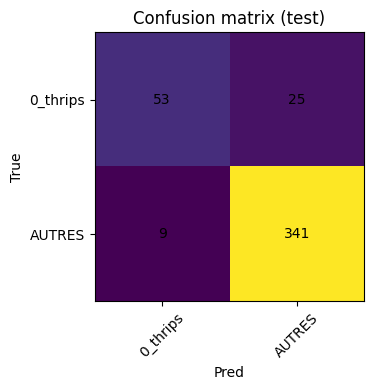

In [10]:
# Évaluation + matrice de confusion

print('--- Évaluation validation ---')
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

print('--- Évaluation test ---')
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f}")

# Prédictions test
y_true = []
y_pred = []

for batch_x, batch_y in test_ds:
    probs = model.predict(batch_x, verbose=0)
    y_true.extend(np.argmax(batch_y.numpy(), axis=1))
    y_pred.extend(np.argmax(probs, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
print('Matrice de confusion (test):')
print(cm)

print('Rapport par classe (test):')
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

# Export PNG
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title('Confusion matrix (test)')
plt.xlabel('Pred')
plt.ylabel('True')
plt.xticks(range(N_CLASSES), CLASSES, rotation=45)
plt.yticks(range(N_CLASSES), CLASSES)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
plt.tight_layout()
cm_path = OUTPUT_DIR / 'confusion_matrix.png'
plt.savefig(cm_path, dpi=200)
plt.show()

